
# Evaluación Parcial 2: Técnicas de Regularización en Deep Learning

## Introducción

En esta evaluación se toma como base el modelo desarrollado en la Evaluación Parcial 1 para clasificar imágenes del dataset Fashion-MNIST.

El objetivo principal es aplicar técnicas de regularización para reducir el sobreajuste u overfitting y mejorar la capacidad de generalización del modelo.

Para esto se comparará el modelo baseline con diferentes experimentos:

- L2 Regularization
- Dropout
- Batch Normalization
- Early Stopping
- Modelo final combinado

Las métricas utilizadas serán:

- Accuracy
- Precision
- Recall
- F1-score
- Gap entre entrenamiento y validación

Además, se analizarán curvas de loss y accuracy para entrenamiento y validación.

Para optimizar el tiempo de ejecución en Google Colab, se trabajará con una muestra reducida del dataset y menos épocas de entrenamiento.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display, Markdown

from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.datasets import fashion_mnist

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)



tf.random.set_seed(42)
np.random.seed(42)

# Config optimizada
EPOCHS_BASE = 3
EPOCHS_EARLY = 10
BATCH_SIZE = 128

TRAIN_SIZE = 15000
VAL_SIZE = 5000
TEST_SIZE = 5000

print("TensorFlow version:", tf.__version__)

gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    print("GPU detectada:", gpu_devices)
else:
    print("No hay GPU activa. El código funcionará, pero será más lento.")




TensorFlow version: 2.20.0
GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]




## 1. Carga del dataset

Se utiliza el dataset Fashion-MNIST, que contiene imágenes en escala de grises de prendas de vestir.

Cada imagen tiene un tamaño de 28x28 píxeles y pertenece a una de 10 clases posibles.

La data se carga directamente desde Keras mediante:

`fashion_mnist.load_data()'

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Forma original x_train_full:", x_train_full.shape)
print("Forma original y_train_full:", y_train_full.shape)
print("Forma original x_test_full:", x_test_full.shape)
print("Forma original y_test_full:", y_test_full.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Forma original x_train_full: (60000, 28, 28)
Forma original y_train_full: (60000,)
Forma original x_test_full: (10000, 28, 28)
Forma original y_test_full: (10000,)



## 2. Visualización inicial de datos

Antes de entrenar los modelos, se visualizan algunas imágenes del dataset para confirmar que los datos fueron cargados correctamente.

Esto permite verificar las clases y la estructura visual del problema de clasificación.


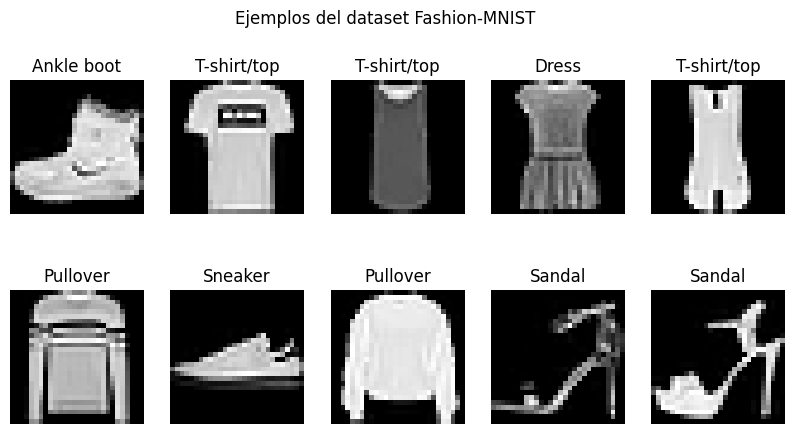

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")

plt.suptitle("Ejemplos del dataset Fashion-MNIST")
plt.show()


## 3. Preprocesamiento de datos

Las imágenes se normalizan dividiendo sus valores por 255. Esto deja los píxeles en un rango entre 0 y 1.

Además, se agrega una dimensión extra para que las imágenes sean compatibles con capas convolucionales.

Originalmente, cada imagen tiene forma:

`(28, 28)`

Luego del preprocesamiento queda con forma:

`(28, 28, 1)`

Para reducir el tiempo de ejecución, se utilizarán:

- 15.000 imágenes para entrenamiento
- 5.000 imágenes para validación
- 5.000 imágenes para test

In [4]:
# Normalización
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0

# Agregar canal para CNN: de (28, 28) a (28, 28, 1)
x_train_full = np.expand_dims(x_train_full, axis=-1)
x_test_full = np.expand_dims(x_test_full, axis=-1)

# Usar muestra reducida para que el entrenamiento sea rápido
x_train = x_train_full[:TRAIN_SIZE]
y_train = y_train_full[:TRAIN_SIZE]

x_val = x_train_full[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
y_val = y_train_full[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

x_test = x_test_full[:TEST_SIZE]
y_test = y_test_full[:TEST_SIZE]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


x_train: (15000, 28, 28, 1)
y_train: (15000,)
x_val: (5000, 28, 28, 1)
y_val: (5000,)
x_test: (5000, 28, 28, 1)
y_test: (5000,)


## 4. Funciones auxiliares

Se crean funciones reutilizables para:

- Compilar modelos
- Graficar accuracy y loss
- Evaluar modelos
- Guardar los resultados en una tabla comparativa

Para acelerar la evaluación, las métricas de entrenamiento se calcularán sobre una muestra de 3.000 registros.

In [5]:
# 6. FUNCIONES AUXILIARES
results = []
histories = {}

def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - {title}")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - {title}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_model(model, experiment_name):
    """
    Evalúa el modelo de forma optimizada.
    Para train usa solo 3.000 imágenes para ahorrar tiempo.
    Para validación usa todo x_val.
    """

    x_train_sample = x_train[:3000]
    y_train_sample = y_train[:3000]

    y_train_pred = np.argmax(model.predict(x_train_sample, verbose=0), axis=1)
    y_val_pred = np.argmax(model.predict(x_val, verbose=0), axis=1)

    train_accuracy = accuracy_score(y_train_sample, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)

    train_precision = precision_score(y_train_sample, y_train_pred, average="macro", zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, average="macro", zero_division=0)

    train_recall = recall_score(y_train_sample, y_train_pred, average="macro", zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average="macro", zero_division=0)

    train_f1 = f1_score(y_train_sample, y_train_pred, average="macro", zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

    gap_accuracy = train_accuracy - val_accuracy

    results.append({
        "Experimento": experiment_name,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Gap Accuracy": gap_accuracy,
        "Train Precision": train_precision,
        "Validation Precision": val_precision,
        "Train Recall": train_recall,
        "Validation Recall": val_recall,
        "Train F1": train_f1,
        "Validation F1": val_f1
    })

    print("====================================================")
    print(f"RESULTADOS: {experiment_name}")
    print("====================================================")
    print(f"Train Accuracy:       {train_accuracy:.4f}")
    print(f"Validation Accuracy:  {val_accuracy:.4f}")
    print(f"Gap Accuracy:         {gap_accuracy:.4f}")
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall:    {val_recall:.4f}")
    print(f"Validation F1-score:  {val_f1:.4f}")
    print("====================================================")

## 5. Modelo Baseline

El modelo baseline corresponde al modelo base utilizado en la Evaluación Parcial 1.

Este modelo se usa como referencia para comparar el impacto de las técnicas de regularización.

La arquitectura base utiliza:

- Conv2D
- MaxPooling2D
- Conv2D
- MaxPooling2D
- Flatten
- Dense
- Dropout
- Dense de salida con Softmax

Este modelo permitirá observar si existe diferencia entre el rendimiento de entrenamiento y validación.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.6808 - loss: 0.9011 - val_accuracy: 0.7766 - val_loss: 0.5861
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8009 - loss: 0.5454 - val_accuracy: 0.8182 - val_loss: 0.4937
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8299 - loss: 0.4702 - val_accuracy: 0.8418 - val_loss: 0.4310


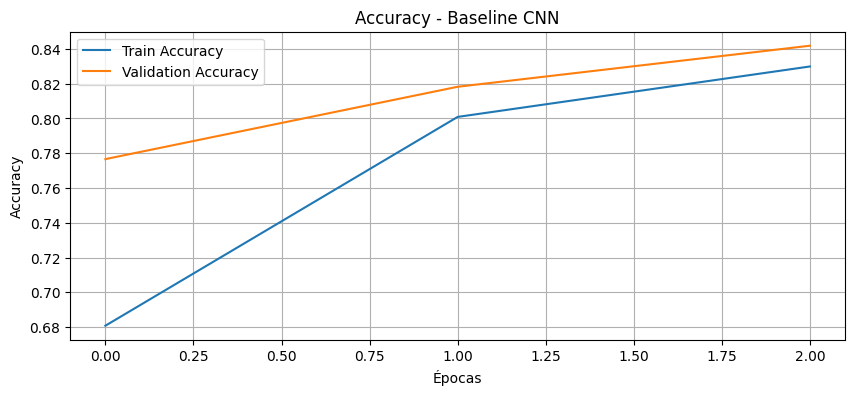

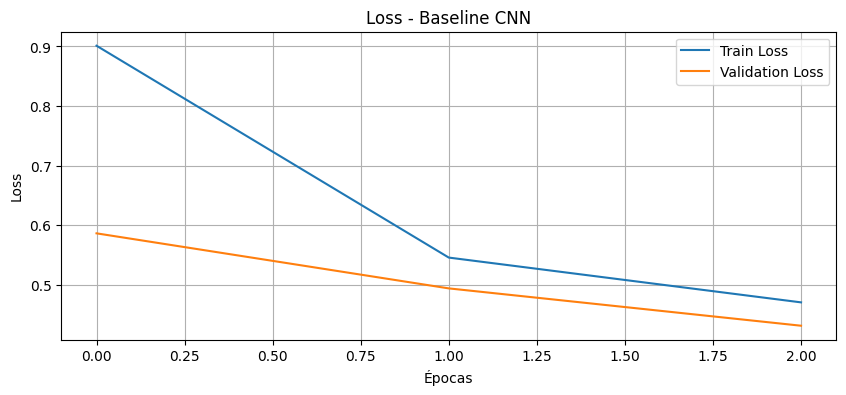

RESULTADOS: Baseline CNN
Train Accuracy:       0.8623
Validation Accuracy:  0.8418
Gap Accuracy:         0.0205
Validation Precision: 0.8400
Validation Recall:    0.8434
Validation F1-score:  0.8369


In [6]:
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


baseline_model = build_baseline_model()
baseline_model.summary()

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE,
    verbose=1
)

histories["Baseline CNN"] = history_baseline

plot_history(history_baseline, "Baseline CNN")
evaluate_model(baseline_model, "Baseline CNN")

## 6. L2 Regularization

La regularización L2 penaliza pesos grandes dentro del modelo.

Esto ayuda a reducir el sobreajuste, evitando que la red memorice excesivamente los datos de entrenamiento.

Se prueban dos valores de lambda:

- 0.001
- 0.01

Un valor pequeño aplica una penalización suave, mientras que un valor más alto aplica una penalización más fuerte.

El objetivo es observar cuál valor reduce mejor el gap entre entrenamiento y validación.

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6743 - loss: 1.1103 - val_accuracy: 0.7832 - val_loss: 0.7538
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7922 - loss: 0.7267 - val_accuracy: 0.8224 - val_loss: 0.6468
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8191 - loss: 0.6430 - val_accuracy: 0.8384 - val_loss: 0.5866


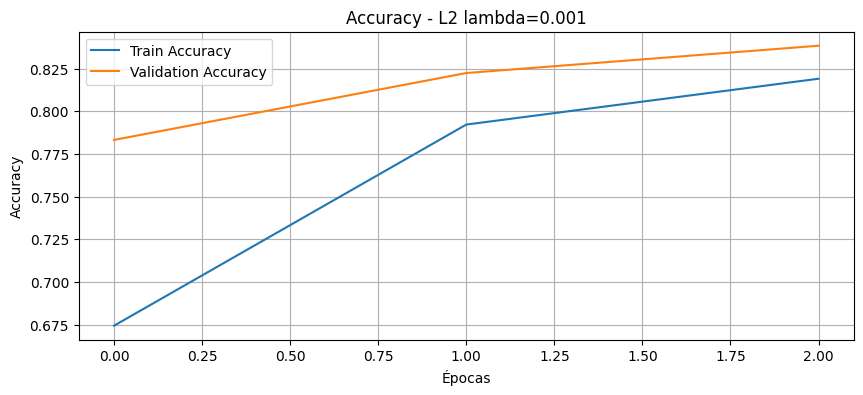

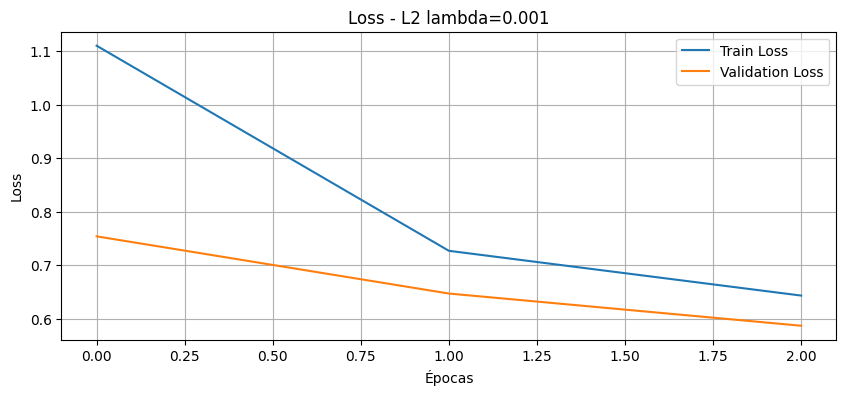

RESULTADOS: L2 lambda=0.001
Train Accuracy:       0.8523
Validation Accuracy:  0.8384
Gap Accuracy:         0.0139
Validation Precision: 0.8375
Validation Recall:    0.8392
Validation F1-score:  0.8379
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.6373 - loss: 1.9680 - val_accuracy: 0.7660 - val_loss: 1.1188
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7607 - loss: 1.0041 - val_accuracy: 0.7910 - val_loss: 0.8694
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7842 - loss: 0.8511 - val_accuracy: 0.8020 - val_loss: 0.7900


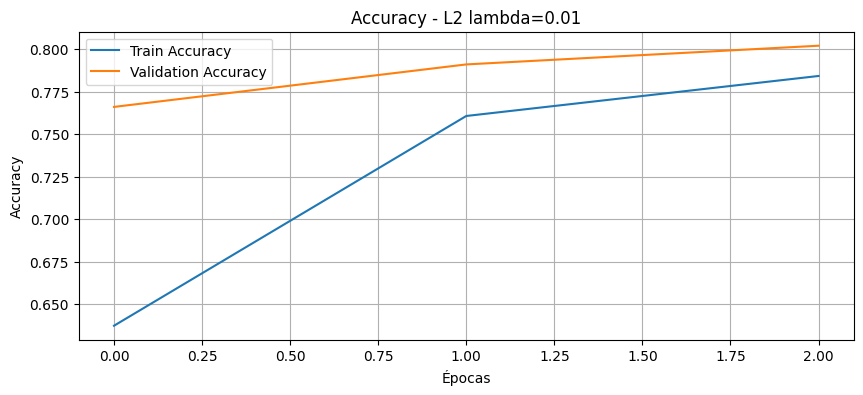

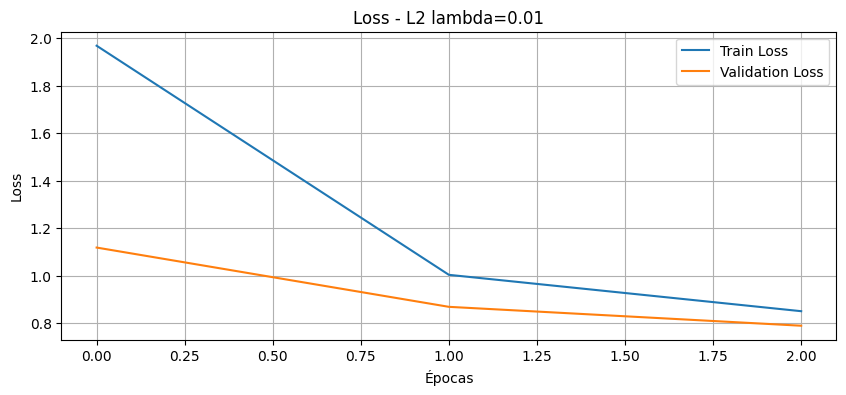

RESULTADOS: L2 lambda=0.01
Train Accuracy:       0.8183
Validation Accuracy:  0.8020
Gap Accuracy:         0.0163
Validation Precision: 0.8052
Validation Recall:    0.8031
Validation F1-score:  0.8011


In [7]:
# 8. L2 REGULARIZATION

def build_l2_model(lambda_value):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            32,
            kernel_size=3,
            activation="relu",
            kernel_regularizer=regularizers.l2(lambda_value)
        ),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            kernel_size=3,
            activation="relu",
            kernel_regularizer=regularizers.l2(lambda_value)
        ),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(lambda_value)
        ),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


for lambda_value in [0.001, 0.01]:
    experiment_name = f"L2 lambda={lambda_value}"

    model_l2 = build_l2_model(lambda_value)

    history_l2 = model_l2.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS_BASE,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[experiment_name] = history_l2

    plot_history(history_l2, experiment_name)
    evaluate_model(model_l2, experiment_name)

## 7. Dropout

Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento.

Esto permite que la red no dependa de neuronas específicas y ayuda a mejorar la generalización.

Se prueban tres tasas:

- 0.2
- 0.5
- 0.8

Una tasa baja puede tener poco efecto regularizador.

Una tasa demasiado alta puede afectar negativamente el aprendizaje, ya que elimina demasiada información durante el entrenamiento.

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.6732 - loss: 0.8999 - val_accuracy: 0.7900 - val_loss: 0.5684
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8057 - loss: 0.5269 - val_accuracy: 0.8166 - val_loss: 0.4961
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8353 - loss: 0.4585 - val_accuracy: 0.8496 - val_loss: 0.4235


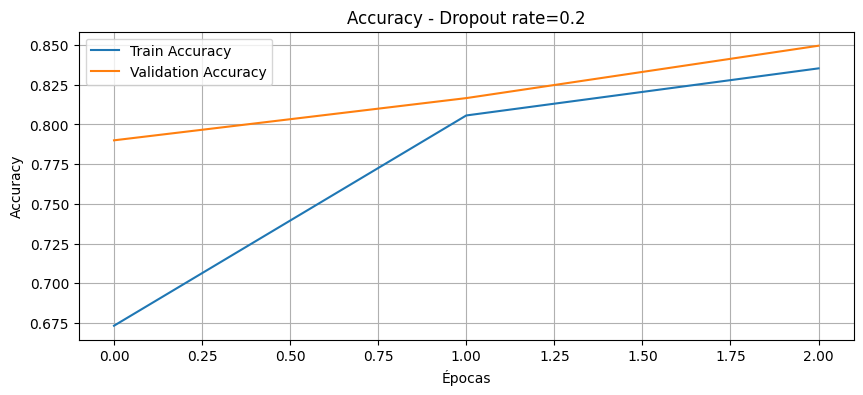

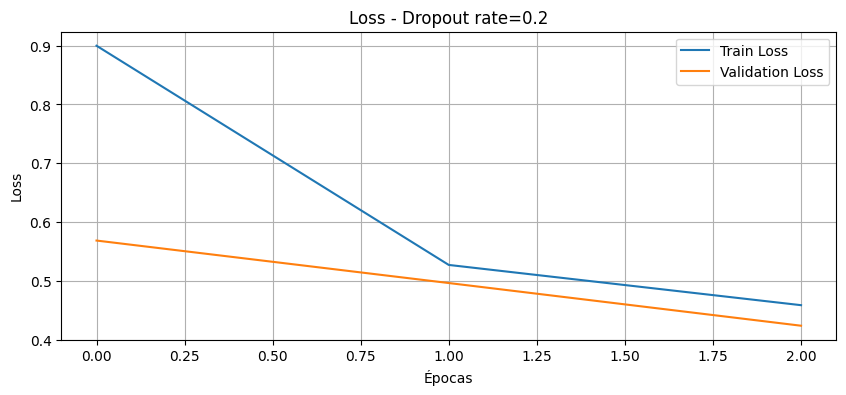

RESULTADOS: Dropout rate=0.2
Train Accuracy:       0.8583
Validation Accuracy:  0.8496
Gap Accuracy:         0.0087
Validation Precision: 0.8500
Validation Recall:    0.8506
Validation F1-score:  0.8477
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6427 - loss: 0.9875 - val_accuracy: 0.7840 - val_loss: 0.5773
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7811 - loss: 0.5983 - val_accuracy: 0.8202 - val_loss: 0.4851
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8147 - loss: 0.5160 - val_accuracy: 0.8344 - val_loss: 0.4470


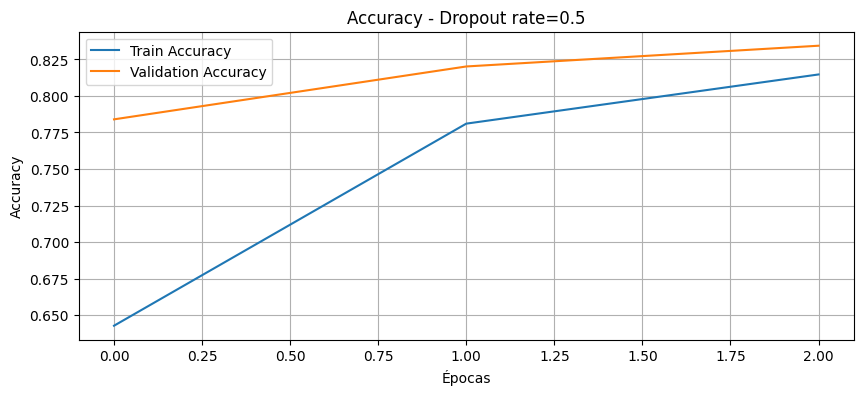

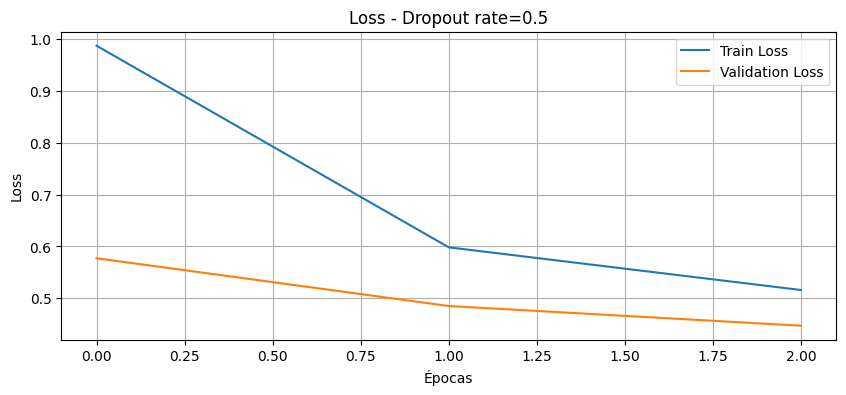

RESULTADOS: Dropout rate=0.5
Train Accuracy:       0.8507
Validation Accuracy:  0.8344
Gap Accuracy:         0.0163
Validation Precision: 0.8354
Validation Recall:    0.8356
Validation F1-score:  0.8331
Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5223 - loss: 1.3151 - val_accuracy: 0.7668 - val_loss: 0.6476
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6898 - loss: 0.8435 - val_accuracy: 0.7908 - val_loss: 0.5475
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7313 - loss: 0.7292 - val_accuracy: 0.8096 - val_loss: 0.5062


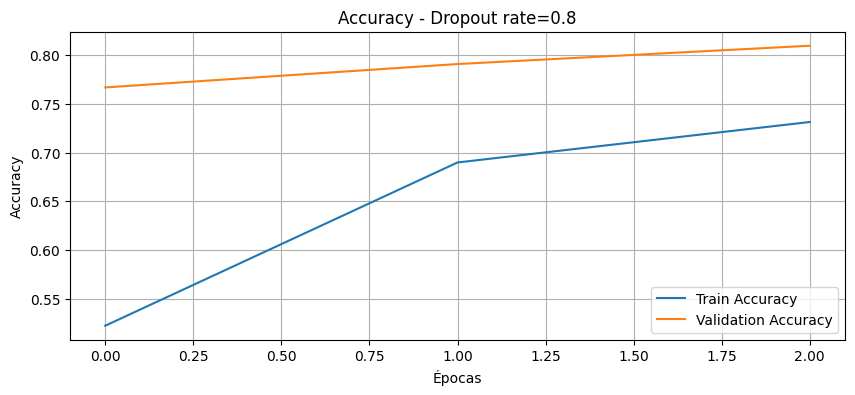

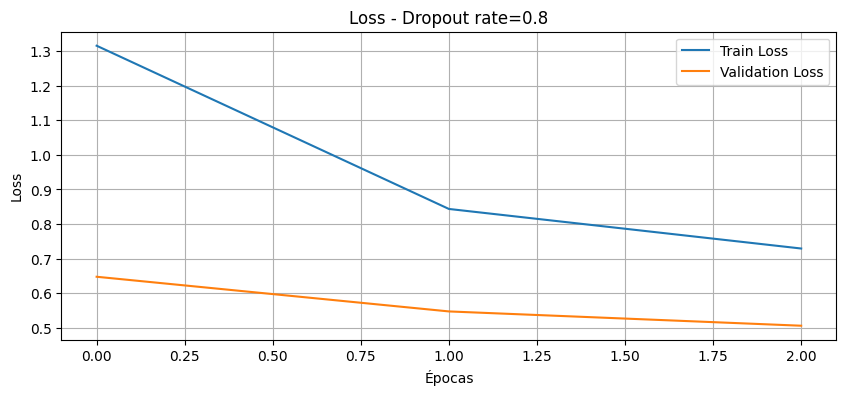

RESULTADOS: Dropout rate=0.8
Train Accuracy:       0.8277
Validation Accuracy:  0.8096
Gap Accuracy:         0.0181
Validation Precision: 0.8046
Validation Recall:    0.8114
Validation F1-score:  0.8030


In [8]:
def build_dropout_model(dropout_rate):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


for dropout_rate in [0.2, 0.5, 0.8]:
    experiment_name = f"Dropout rate={dropout_rate}"

    model_dropout = build_dropout_model(dropout_rate)

    history_dropout = model_dropout.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS_BASE,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[experiment_name] = history_dropout

    plot_history(history_dropout, experiment_name)
    evaluate_model(model_dropout, experiment_name)

## 8. Batch Normalization

Batch Normalization normaliza las activaciones intermedias del modelo.

Esto puede estabilizar el entrenamiento y mejorar la convergencia.

En esta arquitectura se ubica BatchNormalization después de la capa convolucional o densa y antes de la activación ReLU.

Esto permite normalizar la salida de la capa antes de aplicar la función de activación.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7905 - loss: 0.6027 - val_accuracy: 0.1862 - val_loss: 2.3479
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8720 - loss: 0.3647 - val_accuracy: 0.3118 - val_loss: 2.0702
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8987 - loss: 0.2922 - val_accuracy: 0.6732 - val_loss: 1.0388


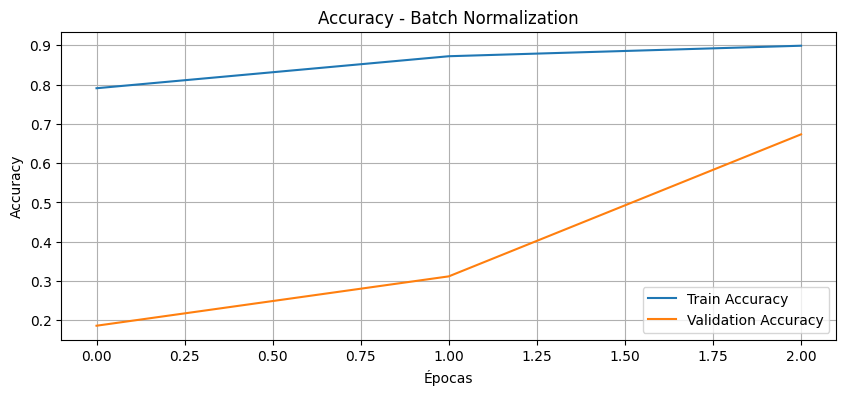

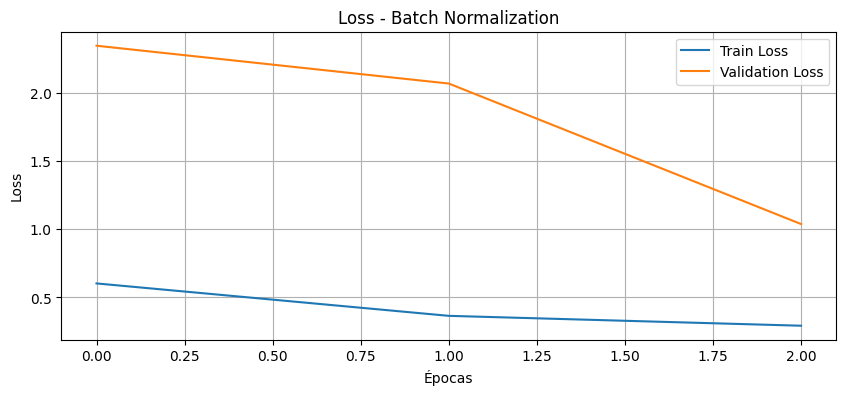

RESULTADOS: Batch Normalization
Train Accuracy:       0.6993
Validation Accuracy:  0.6732
Gap Accuracy:         0.0261
Validation Precision: 0.7220
Validation Recall:    0.6757
Validation F1-score:  0.6378


In [9]:
# 10. BATCH NORMALIZATION


def build_batchnorm_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


batchnorm_model = build_batchnorm_model()
batchnorm_model.summary()

history_batchnorm = batchnorm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE,
    verbose=1
)

histories["Batch Normalization"] = history_batchnorm

plot_history(history_batchnorm, "Batch Normalization")
evaluate_model(batchnorm_model, "Batch Normalization")

## 9. Early Stopping

Early Stopping detiene el entrenamiento cuando la pérdida de validación deja de mejorar.

Se monitorea `val_loss`, porque representa el rendimiento del modelo en datos que no se usan directamente para entrenar.

Se prueban dos valores:

- patience = 3
- patience = 5

Se utiliza `restore_best_weights=True` para recuperar los mejores pesos encontrados durante el entrenamiento.

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6639 - loss: 0.9216 - val_accuracy: 0.7722 - val_loss: 0.5912
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7901 - loss: 0.5673 - val_accuracy: 0.8230 - val_loss: 0.4918
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8203 - loss: 0.4819 - val_accuracy: 0.8434 - val_loss: 0.4371
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8417 - loss: 0.4385 - val_accuracy: 0.8468 - val_loss: 0.4149
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8510 - loss: 0.3995 - val_accuracy: 0.8584 - val_loss: 0.3840
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8616 - loss: 0.3771 - val_accuracy: 0.8622 - val_loss: 0.3744
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8721 - loss: 0.3483 - val_accuracy: 0.8698 - val_loss: 0.3548
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8797 - loss: 0.3311 - val_accuracy: 0

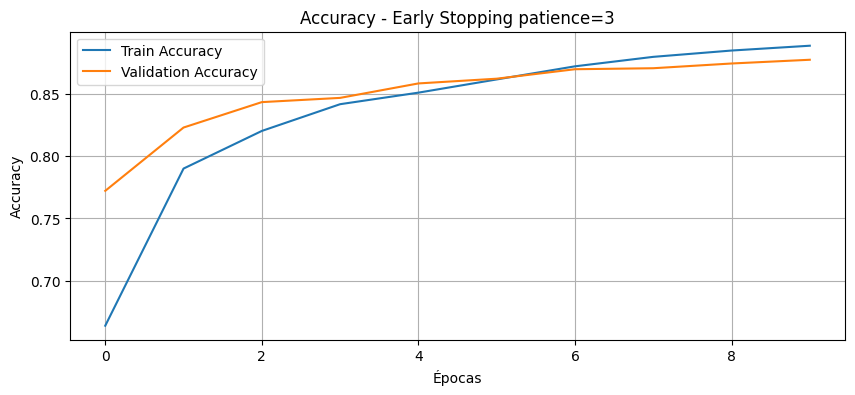

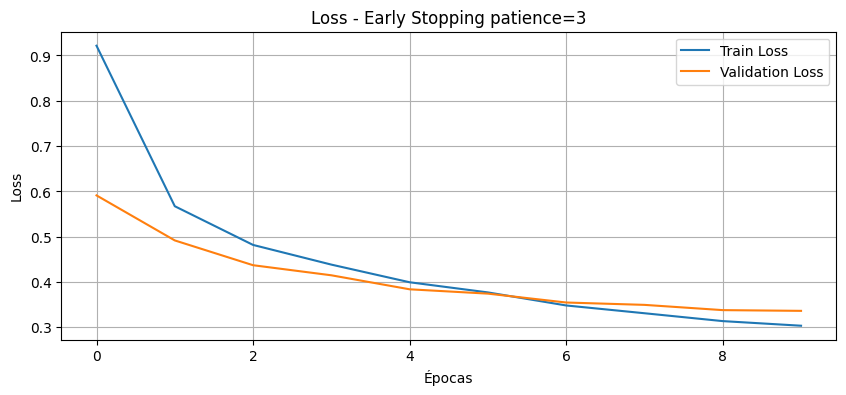

RESULTADOS: Early Stopping patience=3
Train Accuracy:       0.9057
Validation Accuracy:  0.8774
Gap Accuracy:         0.0283
Validation Precision: 0.8787
Validation Recall:    0.8779
Validation F1-score:  0.8780
Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6737 - loss: 0.9095 - val_accuracy: 0.7858 - val_loss: 0.5653
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7978 - loss: 0.5481 - val_accuracy: 0.8292 - val_loss: 0.4810
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8327 - loss: 0.4632 - val_accuracy: 0.8436 - val_loss: 0.4316
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8481 - loss: 0.4229 - val_accuracy: 0.8580 - val_loss: 0.3988
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8613 - loss: 0.3878 - val_accuracy: 0.8628 - val_loss: 0.3818
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8723 - loss: 0.3572 - val_accuracy: 0.8616 - val_loss: 0.3646
Epoch 7/10
118/118 

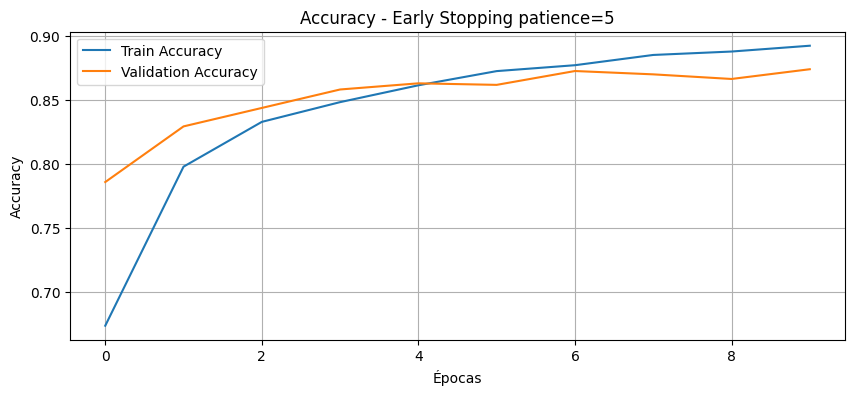

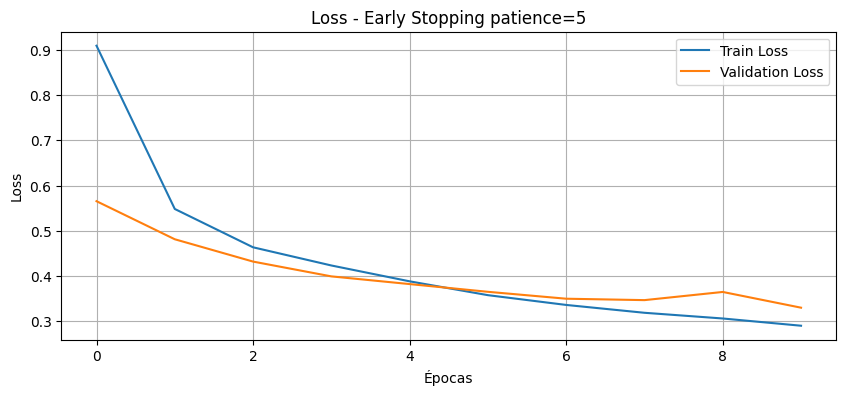

RESULTADOS: Early Stopping patience=5
Train Accuracy:       0.9103
Validation Accuracy:  0.8738
Gap Accuracy:         0.0365
Validation Precision: 0.8771
Validation Recall:    0.8737
Validation F1-score:  0.8748


In [10]:

def build_early_stopping_model():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


for patience_value in [3, 5]:
    experiment_name = f"Early Stopping patience={patience_value}"

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience_value,
        restore_best_weights=True
    )

    model_early = build_early_stopping_model()

    history_early = model_early.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS_EARLY,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )

    histories[experiment_name] = history_early

    print(f"{experiment_name} se detuvo en la época: {len(history_early.history['loss'])}")

    plot_history(history_early, experiment_name)
    evaluate_model(model_early, experiment_name)

## 10. Modelo Final Regularizado

El modelo final combina las principales técnicas de regularización:

- L2 Regularization
- Batch Normalization
- Dropout
- Early Stopping

La finalidad es obtener un modelo más equilibrado, que no solo tenga buen accuracy en entrenamiento, sino que también generalice correctamente en validación y test.

Para este modelo final se usa:

- L2 con lambda = 0.001
- Batch Normalization antes de ReLU
- Dropout con tasa 0.3
- Early Stopping monitoreando `val_loss`

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7014 - loss: 1.1283
Epoch 1: val_loss improved from None to 2.64716, saving model to mejor_modelo_regularizado.keras

Epoch 1: finished saving model to mejor_modelo_regularizado.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.7897 - loss: 0.8695 - val_accuracy: 0.1036 - val_loss: 2.6472
Epoch 2/10
110/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8629 - loss: 0.6344
Epoch 2: val_loss improved from 2.64716 to 2.40829, saving model to mejor_modelo_regularizado.keras

Epoch 2: finished saving model to mejor_modelo_regularizado.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8694 - loss: 0.6015 - val_accuracy: 0.3740 - val_loss: 2.4083
Epoch 3/10
108/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8904 - loss: 0.5230
Epoch 3: val_loss improved from 2.40829 to 1.44480, saving model to mejor_modelo_regularizado.keras

Epoch 3: finished saving model to mejor_modelo_regularizado.keras
118/118

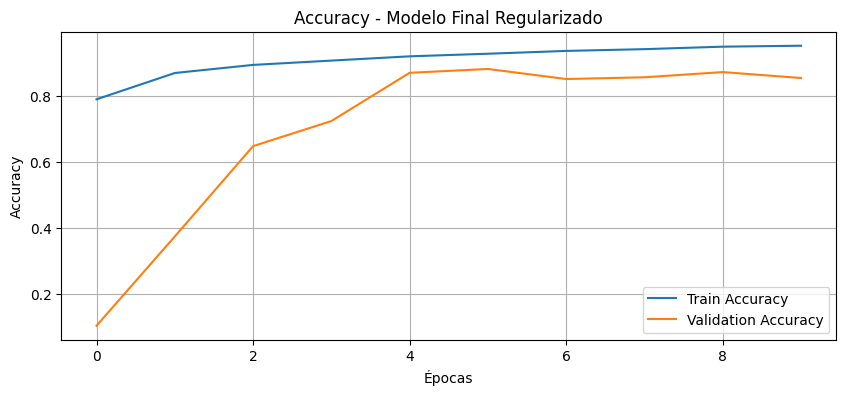

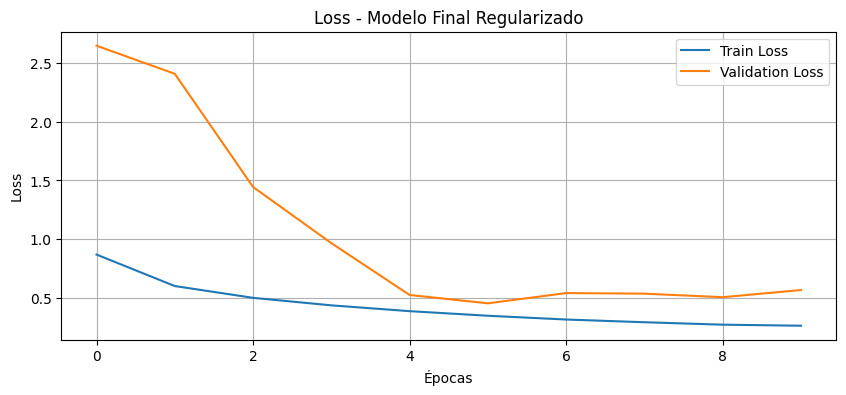

RESULTADOS: Modelo Final Regularizado
Train Accuracy:       0.9387
Validation Accuracy:  0.8816
Gap Accuracy:         0.0571
Validation Precision: 0.8854
Validation Recall:    0.8816
Validation F1-score:  0.8826


In [11]:
# 12. MODELO FINAL REGULARIZADO

def build_final_model():
    l2_value = 0.001

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            32,
            kernel_size=3,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(
            64,
            kernel_size=3,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),

        layers.Dense(
            128,
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),

        layers.Dense(10, activation="softmax")
    ])

    return compile_model(model)


early_stop_final = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "mejor_modelo_regularizado.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

final_model = build_final_model()
final_model.summary()

history_final = final_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS_EARLY,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_final, checkpoint],
    verbose=1
)

histories["Modelo Final Regularizado"] = history_final

print(f"Modelo final se detuvo en la época: {len(history_final.history['loss'])}")

plot_history(history_final, "Modelo Final Regularizado")
evaluate_model(final_model, "Modelo Final Regularizado")


## 11. Tabla comparativa global

En esta sección se comparan todos los experimentos realizados.

La tabla incluye métricas de entrenamiento y validación:

- Accuracy
- Precision
- Recall
- F1-score
- Gap entre entrenamiento y validación

El gap entre entrenamiento y validación permite analizar si el modelo presenta sobreajuste.

Un gap menor indica que el modelo tiene un comportamiento más equilibrado entre los datos de entrenamiento y validación.

In [12]:
df_results = pd.DataFrame(results)

df_results_sorted = df_results.sort_values(
    by=["Validation F1", "Validation Accuracy"],
    ascending=False
)

display(df_results_sorted)

df_results_sorted.to_csv("resultados_experimentos_regularizacion.csv", index=False)

print("Archivo resultados_experimentos_regularizacion.csv creado correctamente.")

,Experimento,Train Accuracy,Validation Accuracy,Gap Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1
9,Modelo Final Regularizado,0.938667,0.8816,0.057067,0.940448,0.885369,0.937764,0.881619,0.938393,0.882642
7,Early Stopping patience=3,0.905667,0.8774,0.028267,0.905361,0.878684,0.904588,0.877890,0.904001,0.877966
8,Early Stopping patience=5,0.910333,0.8738,0.036533,0.909896,0.877146,0.909046,0.873656,0.909125,0.874784
3,Dropout rate=0.2,0.858333,0.8496,0.008733,0.857963,0.850023,0.857827,0.850614,0.852222,0.847666
1,L2 lambda=0.001,0.852333,0.8384,0.013933,0.847374,0.837477,0.851127,0.839210,0.847860,0.837875
0,Baseline CNN,0.862333,0.8418,0.020533,0.861091,0.839981,0.861287,0.843430,0.854827,0.836900
4,Dropout rate=0.5,0.850667,0.8344,0.016267,0.847658,0.835442,0.849527,0.835624,0.846249,0.833116
5,Dropout rate=0.8,0.827667,0.8096,0.018067,0.817987,0.804562,0.826373,0.811447,0.816540,0.802956
2,L2 lambda=0.01,0.818333,0.8020,0.016333,0.816925,0.805246,0.817866,0.803124,0.814108,0.801128
6,Batch Normalization,0.699333,0.6732,0.026133,0.727377,0.722013,0.701224,0.675651,0.659985,0.637805


Archivo resultados_experimentos_regularizacion.csv creado correctamente.


## 12. Gráficos comparativos de métricas

A continuación se grafican las métricas principales de validación para comparar el rendimiento de los experimentos.

Se analiza:

- Validation Accuracy
- Validation F1-score
- Gap entre Train Accuracy y Validation Accuracy

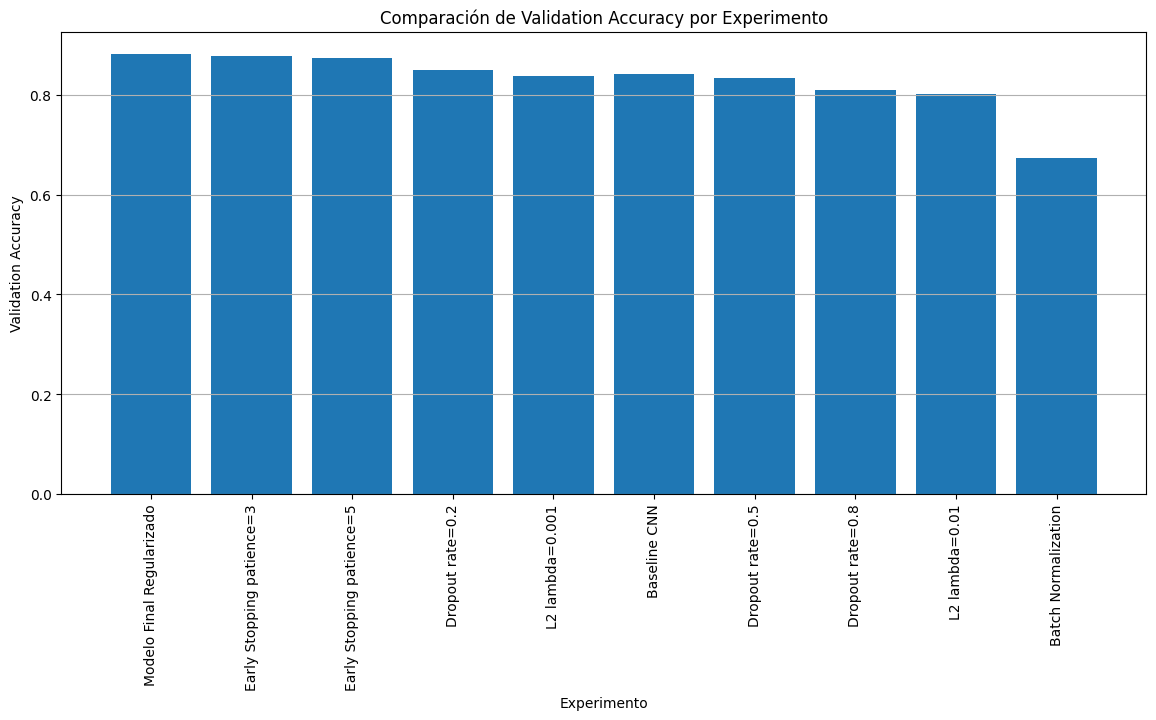

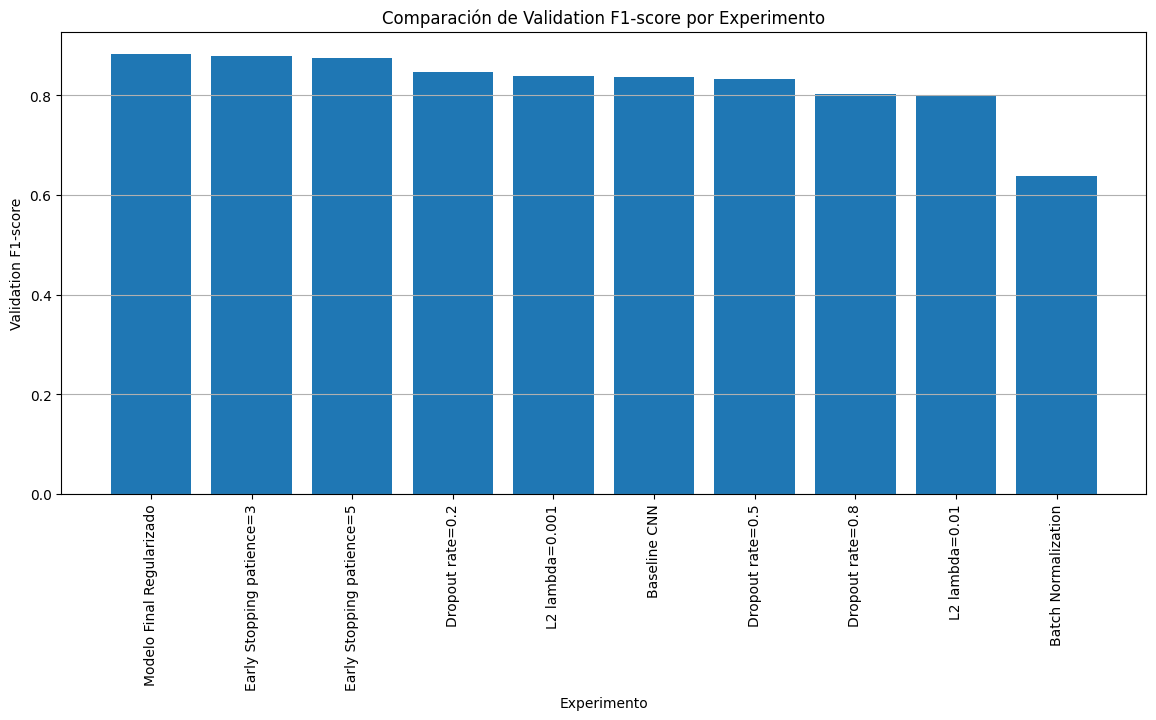

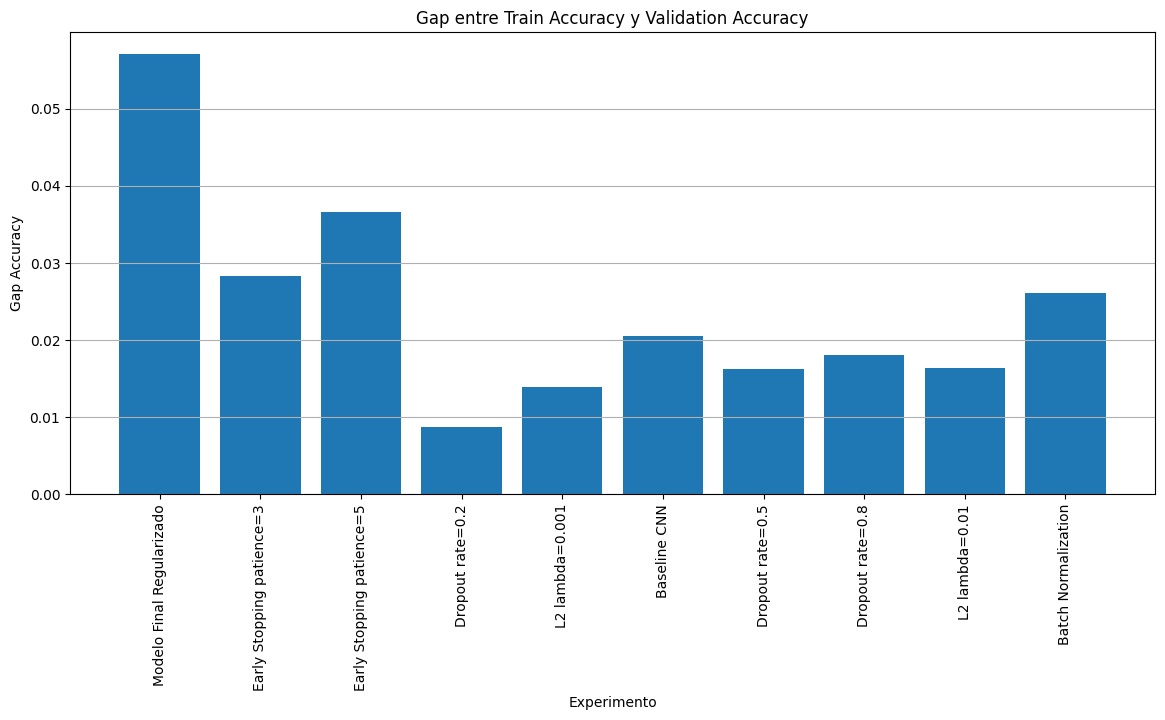

In [13]:
plt.figure(figsize=(14, 6))
plt.bar(df_results_sorted["Experimento"], df_results_sorted["Validation Accuracy"])
plt.xticks(rotation=90)
plt.title("Comparación de Validation Accuracy por Experimento")
plt.xlabel("Experimento")
plt.ylabel("Validation Accuracy")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(df_results_sorted["Experimento"], df_results_sorted["Validation F1"])
plt.xticks(rotation=90)
plt.title("Comparación de Validation F1-score por Experimento")
plt.xlabel("Experimento")
plt.ylabel("Validation F1-score")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(df_results_sorted["Experimento"], df_results_sorted["Gap Accuracy"])
plt.xticks(rotation=90)
plt.title("Gap entre Train Accuracy y Validation Accuracy")
plt.xlabel("Experimento")
plt.ylabel("Gap Accuracy")
plt.grid(axis="y")
plt.show()

## 13. Comparación Baseline vs Modelo Final

En esta sección se comparan directamente las curvas de validación del modelo baseline y del modelo final regularizado.

Esto permite observar si el modelo final mejora la estabilidad de la validación y reduce el sobreajuste.

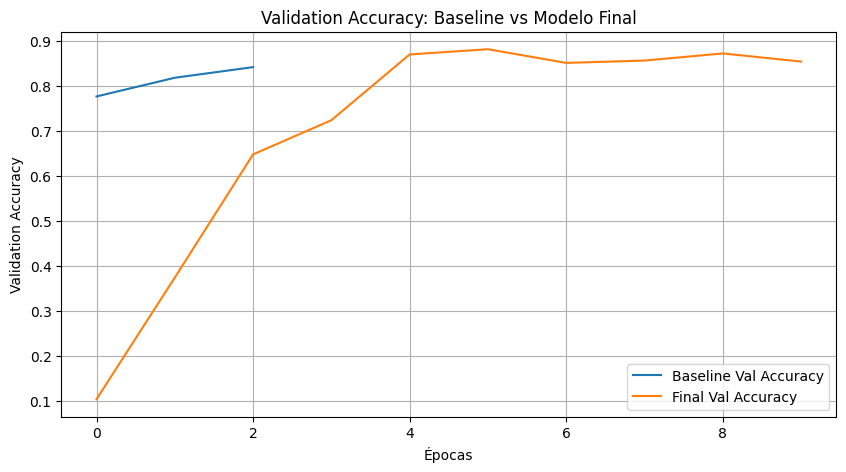

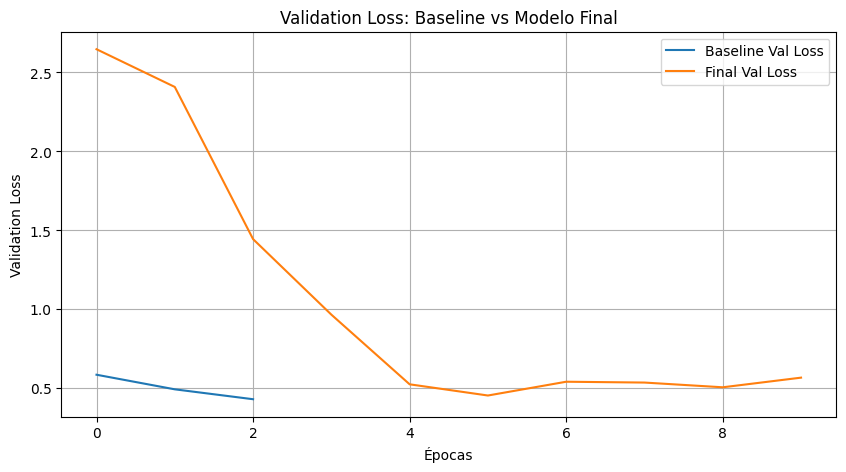

In [14]:
# 15. COMPARACIÓN BASELINE VS MODELO FINAL


plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline Val Accuracy")
plt.plot(history_final.history["val_accuracy"], label="Final Val Accuracy")
plt.title("Validation Accuracy: Baseline vs Modelo Final")
plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history["val_loss"], label="Baseline Val Loss")
plt.plot(history_final.history["val_loss"], label="Final Val Loss")
plt.title("Validation Loss: Baseline vs Modelo Final")
plt.xlabel("Épocas")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 14. Evaluación final en test

Después de comparar los modelos, se evalúa el modelo final regularizado sobre el conjunto de test.

El conjunto de test permite medir el rendimiento final con datos que no fueron utilizados durante el entrenamiento ni durante la validación.

In [15]:
# 16. EVALUACIÓN FINAL EN TEST


test_loss, test_accuracy = final_model.evaluate(x_test, y_test, verbose=0)

print("====================================================")
print("RESULTADOS FINALES EN TEST")
print("====================================================")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("====================================================")

y_test_pred = np.argmax(final_model.predict(x_test, verbose=0), axis=1)

print("Classification Report - Modelo Final")
print(classification_report(y_test, y_test_pred, target_names=class_names, zero_division=0))

RESULTADOS FINALES EN TEST
Test Loss:     0.4845
Test Accuracy: 0.8740
Classification Report - Modelo Final
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.79      0.83       507
     Trouser       0.99      0.97      0.98       481
    Pullover       0.81      0.82      0.81       521
       Dress       0.88      0.89      0.88       500
        Coat       0.83      0.72      0.77       521
      Sandal       0.97      0.95      0.96       485
       Shirt       0.60      0.76      0.67       482
     Sneaker       0.92      0.95      0.93       500
         Bag       0.98      0.95      0.97       526
  Ankle boot       0.96      0.95      0.95       477

    accuracy                           0.87      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.87      0.88      5000



## 15. Matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo por cada clase.

Esto ayuda a identificar qué categorías son clasificadas correctamente y cuáles generan mayor confusión.

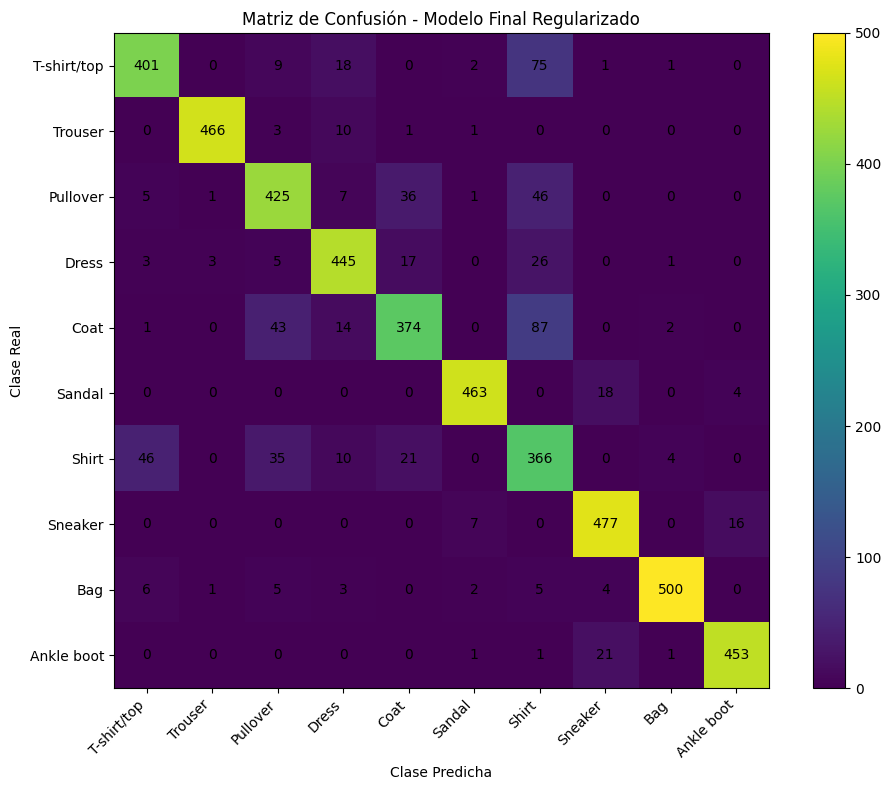

In [16]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Matriz de Confusión - Modelo Final Regularizado")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")
plt.xticks(np.arange(10), class_names, rotation=45, ha="right")
plt.yticks(np.arange(10), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 16. Predicciones visuales

Se muestran ejemplos del conjunto de test junto con su clase real y la clase predicha por el modelo final.

Esto permite revisar visualmente algunos resultados del modelo.

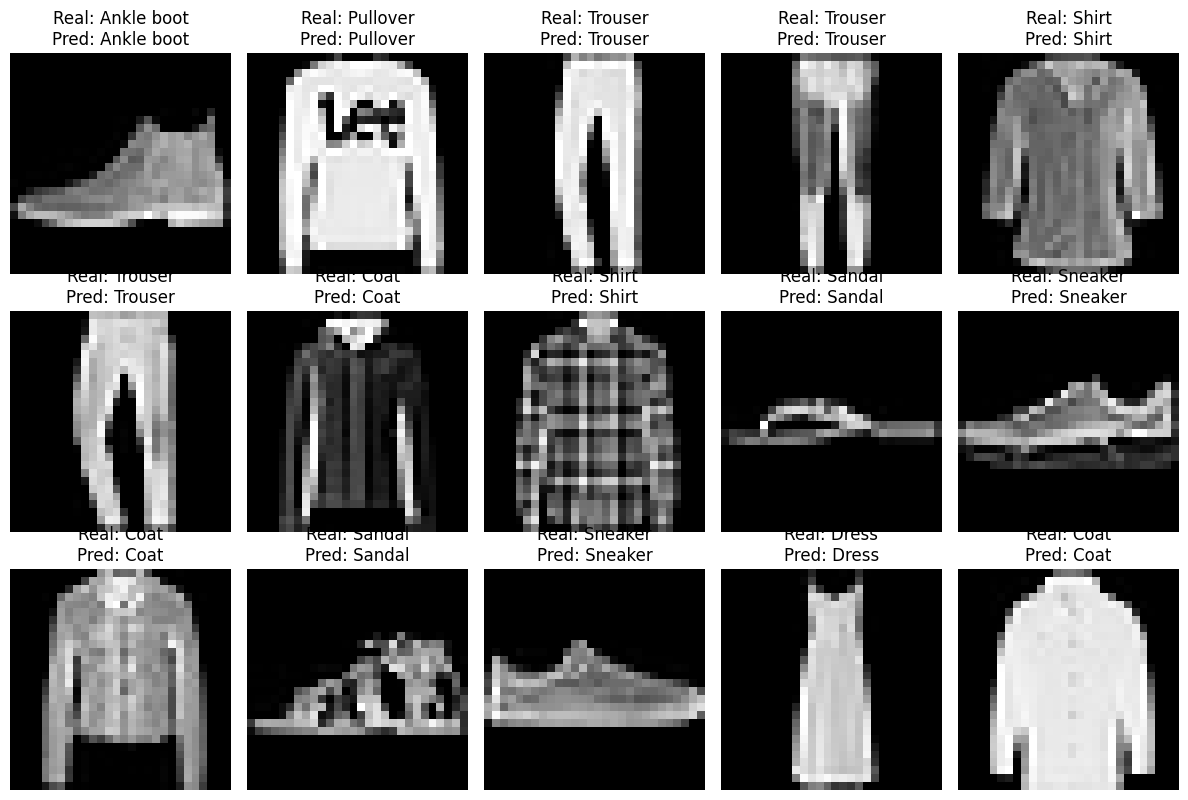

In [17]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    real_label = class_names[y_test[i]]
    pred_label = class_names[y_test_pred[i]]

    plt.title(f"Real: {real_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 17. Análisis del mejor experimento

Se identifica el mejor experimento según el F1-score de validación.

El F1-score es útil porque combina precision y recall, entregando una visión más completa del rendimiento del modelo.

In [18]:
best_experiment = df_results_sorted.iloc[0]

print("====================================================")
print("MEJOR EXPERIMENTO SEGÚN VALIDATION F1-SCORE")
print("====================================================")
print(f"Experimento:          {best_experiment['Experimento']}")
print(f"Validation Accuracy:  {best_experiment['Validation Accuracy']:.4f}")
print(f"Validation F1-score:  {best_experiment['Validation F1']:.4f}")
print(f"Gap Accuracy:         {best_experiment['Gap Accuracy']:.4f}")
print("====================================================")


MEJOR EXPERIMENTO SEGÚN VALIDATION F1-SCORE
Experimento:          Modelo Final Regularizado
Validation Accuracy:  0.8816
Validation F1-score:  0.8826
Gap Accuracy:         0.0571
